# Part 2 — AI Rainfall Generation: TimeGAN vs Bartlett–Lewis (v3)
## Fixing the curves that v2 could not fit — and a richer visual diagnosis

**MSc EEDS — Imperial College London**

---

## 0.1  Where v2 left us

The v2 notebook trained a season-conditioned, two-channel TimeGAN and compared it with the Bartlett–Lewis model (v7 parameters) on a common scoreboard. Two families of statistics behaved very differently:

| Curve | v2 verdict |
|---|---|
| Mean, wet-hour fraction, intensity body | ✅ essentially fixed by the occurrence channel (mean error 24 % → 6 %) |
| **Autocorrelation (ACF), aggregated proportion-dry, spells/storms** | ❌ still badly off — generated wet hours are spread too evenly (AR1 error ≈ 220 %) |
| **Extreme tail** | ❌ block maxima under-generated |

One cause, several symptoms: **the GAN does not cluster its wet hours the way real storms do.**

## 0.2  What v3 does about it

**First, the honest research note.** The obvious "deep-learning" fix is to add the missing statistics to the generator's loss (an ACF-matching term, a tail term) — the GAN analogue of the method of moments. We prototyped this twice. With strong weights the generator **collapsed to permanent drought**; with stabilised, warm-up variants it survived but learned to *decouple its two channels* (putting its rain where the occurrence gate is shut) — the losses were satisfied, the rainfall was not. At our CPU scale, in-training statistical losses destabilise more than they teach. We report this as a finding, not a failure to try.

**The adopted fix comes from hydrology, not deep learning: the Schaake shuffle** (Clark et al., *J. Hydrometeorology*, 2004) — the standard post-processing of ensemble weather generators. The idea is disarmingly simple:

> Keep the *amplitudes* the GAN generates (its marginal distribution is good — v2 proved it), but **re-arrange them in time following the rank pattern of a randomly drawn real block**. Big values land where a real storm would put its peak; zeros gather into realistic dry spells.

The amplitudes stay 100 % TimeGAN; the *ordering* is borrowed from an observed template. This is a declared, literature-standard hybrid — and it turns the temporal-structure problem from "hope the GAN learns it" into "guaranteed by construction". The evaluation then shows **three generators**: Bartlett–Lewis, raw TimeGAN, and TimeGAN + Schaake — so the reader sees exactly what each ingredient buys.

**Second, more diagnosis.** v3 adds the visualisations the earlier versions lacked: the **ACF before/after** (the "fixed curve" figure), **statistics-versus-aggregation-scale curves** (pDry and variance from 1 h to 24 h), an **intensity quantile–quantile plot**, and the **seasonal cycle** — every one compared across the three generators and the observations.

## 0.3  Reminder — the machinery (unchanged from v2)

Same masked Heathrow record, same two-channel 96-h windows, same five GRU networks and three training phases, same season models (DJF/MAM/JJA/SON), same calibrated occurrence threshold, same 20-member ensembles, same Bartlett–Lewis v7 baseline. Anything that changed is in §5 (the shuffle) and §7–§10 (the new diagnostics) — so any difference in results is attributable to the shuffle, not to retuning.

## 1. Setup

In [1]:
%matplotlib inline
import warnings, time, os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from scipy.stats import skew as scipy_skew
from pybl.models import BLRPRx, BLRPRx_params
warnings.filterwarnings('ignore'); plt.rcParams.update({'figure.dpi':110,'font.size':11})
SEED = 20240601; torch.manual_seed(SEED); np.random.seed(SEED)
DISS_ROOT = r'C:\Users\rajab\OneDrive\Bureau\DISSERTATION'
def find_file(rel, fb=()):
    for r in ['.','..','../..',DISS_ROOT]:
        p = Path(r)/rel
        if p.exists(): return str(p.resolve())
    for c in fb:
        if Path(c).exists(): return str(Path(c).resolve())
    raise FileNotFoundError(rel)
DATA_PATH = find_file('Data/Heathrow1949-2022.csv', ['Heathrow1949-2022.csv'])
BL_PARAMS = find_file('Claude/outputs/heathrow_v7/v7_parameters.csv', ['outputs/heathrow_v7/v7_parameters.csv'])
L = 96; THRESH = 0.05
SEASONS = {'DJF':[12,1,2], 'MAM':[3,4,5], 'JJA':[6,7,8], 'SON':[9,10,11]}
SEASON_LONG = {'DJF':'Winter','MAM':'Spring','JJA':'Summer','SON':'Autumn'}
N_ENS = 20
COL = {'Observed':'#1f77b4', 'Bartlett-Lewis':'#2ca02c', 'TimeGAN raw':'#d62728', 'TimeGAN+Schaake':'#9467bd'}
DAYS_IN_MONTH = [31,28.25,31,30,31,30,31,31,30,31,30,31]
FIG_DIR = Path('outputs/timegan_v3'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def show(fig, name): fig.savefig(FIG_DIR/f'{name}.png', dpi=150, bbox_inches='tight'); plt.show()
print('Setup done. torch', torch.__version__)

Setup done. torch 2.12.1+cpu


## 2. Data — two-channel seasonal windows (as v2)

96-hour windows per season; **occurrence** (wet/dry) and **intensity** (scaled log) channels. Training uses overlapping windows (stride 24 h); evaluation uses non-overlapping blocks.

In [2]:
d = pd.read_csv(DATA_PATH); d.columns = d.columns.str.strip()
d['datatime'] = pd.to_datetime(d['datatime'], format='%Y/%m/%d %H:%M'); d = d.set_index('datatime').sort_index()
s = pd.Series(d['Heathrow'].astype(float).to_numpy(), index=d.index)
mz = s.resample('MS').sum(); dead = set(mz[mz==0].index.to_period('M'))
rain = s.mask(s.index.to_period('M').isin(dead))
def windows(months, stride):
    out = []; md = rain[rain.index.month.isin(months)]
    for (_, _), g in md.groupby([md.index.year, md.index.month]):
        v = g.to_numpy()
        if not np.isfinite(v).all(): continue
        for st in range(0, len(v)-L+1, stride): out.append(v[st:st+L])
    return np.array(out)
train_wins = {sn: windows(ms, 24) for sn, ms in SEASONS.items()}
obs_blocks = {sn: windows(ms, L) for sn, ms in SEASONS.items()}
XMAX = {sn: np.log1p(train_wins[sn]).max() for sn in SEASONS}
wet_frac_obs = {sn: float((train_wins[sn] > 0).mean()) for sn in SEASONS}
for sn in SEASONS:
    print(f'{sn}: {len(train_wins[sn])} training windows | {len(obs_blocks[sn])} evaluation blocks | wet fraction {wet_frac_obs[sn]:.3f}')

DJF: 5827 training windows | 1505 evaluation blocks | wet fraction 0.101
MAM: 6059 training windows | 1533 evaluation blocks | wet fraction 0.083
JJA: 6059 training windows | 1533 evaluation blocks | wet fraction 0.066
SON: 6068 training windows | 1554 evaluation blocks | wet fraction 0.089


## 3. The TimeGAN (identical to v2)

Same five one-layer GRUs, same three phases. Keeping the model *frozen* relative to v2 is deliberate: v3's improvements must come from the post-processing, measurably.

In [3]:
H = 32; F = 2
class Net(nn.Module):
    def __init__(self, n_in, n_out, sigmoid=True):
        super().__init__()
        self.gru = nn.GRU(n_in, H, num_layers=1, batch_first=True)
        self.head = nn.Linear(H, n_out); self.sigmoid = sigmoid
    def forward(self, x):
        h, _ = self.gru(x); y = self.head(h)
        return torch.sigmoid(y) if self.sigmoid else y
def make_model(seed):
    torch.manual_seed(seed)
    nets = {'emb':Net(F,H), 'rec':Net(H,F), 'gen':Net(F,H), 'sup':Net(H,H), 'dis':Net(H,1,sigmoid=False)}
    opt  = {'E': torch.optim.Adam(list(nets['emb'].parameters())+list(nets['rec'].parameters()), lr=1e-3),
            'S': torch.optim.Adam(nets['sup'].parameters(), lr=1e-3),
            'G': torch.optim.Adam(list(nets['gen'].parameters())+list(nets['sup'].parameters()), lr=1e-3),
            'D': torch.optim.Adam(nets['dis'].parameters(), lr=1e-3)}
    return {'nets':nets, 'opt':opt, 'hist':{'ae':[], 'sup':[], 'g':[], 'd':[]}}
def to_tensor(W, sn):
    occ = (W > 0).astype(np.float32); inten = (np.log1p(W)/XMAX[sn]).astype(np.float32)
    return torch.tensor(np.stack([occ, inten], axis=-1))
mse, bce = nn.MSELoss(), nn.BCEWithLogitsLoss()
def phase12(state, data, n_ae=1200, n_sup=800, batch=128):
    nets, opt, hist = state['nets'], state['opt'], state['hist']; N = len(data)
    def rb(): return data[torch.randint(0, N, (batch,))]
    for i in range(n_ae):
        x = rb(); loss = mse(nets['rec'](nets['emb'](x)), x)
        opt['E'].zero_grad(); loss.backward(); opt['E'].step(); hist['ae'].append(loss.item())
    for i in range(n_sup):
        h = nets['emb'](rb()).detach(); loss = mse(nets['sup'](h)[:, :-1], h[:, 1:])
        opt['S'].zero_grad(); loss.backward(); opt['S'].step(); hist['sup'].append(loss.item())
    return state
def phase3(state, data, n_joint=500, batch=128):
    nets, opt, hist = state['nets'], state['opt'], state['hist']; N = len(data)
    def rb(): return data[torch.randint(0, N, (batch,))]
    ones, zeros = torch.ones(batch, L, 1), torch.zeros(batch, L, 1)
    for i in range(n_joint):
        for _ in range(2):
            x = rb(); z = torch.rand(batch, L, F)
            h = nets['emb'](x); e_hat = nets['sup'](nets['gen'](z)); x_hat = nets['rec'](e_hat)
            g = bce(nets['dis'](e_hat), ones) \
              + 10*mse(nets['sup'](h.detach())[:, :-1], h.detach()[:, 1:]) \
              + 100*(torch.abs(x_hat.mean(dim=(0,1))-x.mean(dim=(0,1))).sum()
                     + torch.abs(x_hat.std(dim=(0,1))-x.std(dim=(0,1))).sum())
            opt['G'].zero_grad(); g.backward(); opt['G'].step()
            x = rb(); le = mse(nets['rec'](nets['emb'](x)), x)
            opt['E'].zero_grad(); le.backward(); opt['E'].step()
        x = rb(); z = torch.rand(batch, L, F)
        dl = bce(nets['dis'](nets['emb'](x).detach()), ones) + bce(nets['dis'](nets['sup'](nets['gen'](z)).detach()), zeros)
        if dl.item() > 0.15:
            opt['D'].zero_grad(); dl.backward(); opt['D'].step()
        hist['g'].append(g.item()); hist['d'].append(dl.item())
    return state
print('TimeGAN defined (identical to v2).')

TimeGAN defined (identical to v2).


## 4. Training the four seasonal models

Same budget as v2 (1 200 + 800 + 1 000 steps per season, phase 3 split in two for the execution budget). ≈ 75 minutes of CPU in total — the price of a fair, frozen-architecture comparison.

In [4]:
TG = {}; t0 = time.time()
TG['DJF'] = phase12(make_model(SEED+1), to_tensor(train_wins['DJF'], 'DJF'))
print(f'DJF phases 1-2: {time.time()-t0:.0f} s')

DJF phases 1-2: 126 s


In [5]:
t0=time.time(); TG['DJF'] = phase3(TG['DJF'], to_tensor(train_wins['DJF'], 'DJF')); print(f'DJF phase 3a: {time.time()-t0:.0f} s')

DJF phase 3a: 347 s


In [6]:
t0=time.time(); TG['DJF'] = phase3(TG['DJF'], to_tensor(train_wins['DJF'], 'DJF')); print(f'DJF phase 3b: {time.time()-t0:.0f} s')

DJF phase 3b: 347 s


In [7]:
t0=time.time(); TG['MAM'] = phase12(make_model(SEED+2), to_tensor(train_wins['MAM'], 'MAM')); print(f'MAM phases 1-2: {time.time()-t0:.0f} s')

MAM phases 1-2: 129 s


In [8]:
t0=time.time(); TG['MAM'] = phase3(TG['MAM'], to_tensor(train_wins['MAM'], 'MAM')); print(f'MAM phase 3a: {time.time()-t0:.0f} s')

MAM phase 3a: 355 s


In [9]:
t0=time.time(); TG['MAM'] = phase3(TG['MAM'], to_tensor(train_wins['MAM'], 'MAM')); print(f'MAM phase 3b: {time.time()-t0:.0f} s')

MAM phase 3b: 344 s


In [10]:
t0=time.time(); TG['JJA'] = phase12(make_model(SEED+3), to_tensor(train_wins['JJA'], 'JJA')); print(f'JJA phases 1-2: {time.time()-t0:.0f} s')

JJA phases 1-2: 129 s


In [11]:
t0=time.time(); TG['JJA'] = phase3(TG['JJA'], to_tensor(train_wins['JJA'], 'JJA')); print(f'JJA phase 3a: {time.time()-t0:.0f} s')

JJA phase 3a: 349 s


In [12]:
t0=time.time(); TG['JJA'] = phase3(TG['JJA'], to_tensor(train_wins['JJA'], 'JJA')); print(f'JJA phase 3b: {time.time()-t0:.0f} s')

JJA phase 3b: 340 s


In [13]:
t0=time.time(); TG['SON'] = phase12(make_model(SEED+4), to_tensor(train_wins['SON'], 'SON')); print(f'SON phases 1-2: {time.time()-t0:.0f} s')

SON phases 1-2: 124 s


In [14]:
t0=time.time(); TG['SON'] = phase3(TG['SON'], to_tensor(train_wins['SON'], 'SON')); print(f'SON phase 3a: {time.time()-t0:.0f} s')

SON phase 3a: 352 s


In [15]:
t0=time.time(); TG['SON'] = phase3(TG['SON'], to_tensor(train_wins['SON'], 'SON')); print(f'SON phase 3b: {time.time()-t0:.0f} s')

SON phase 3b: 350 s


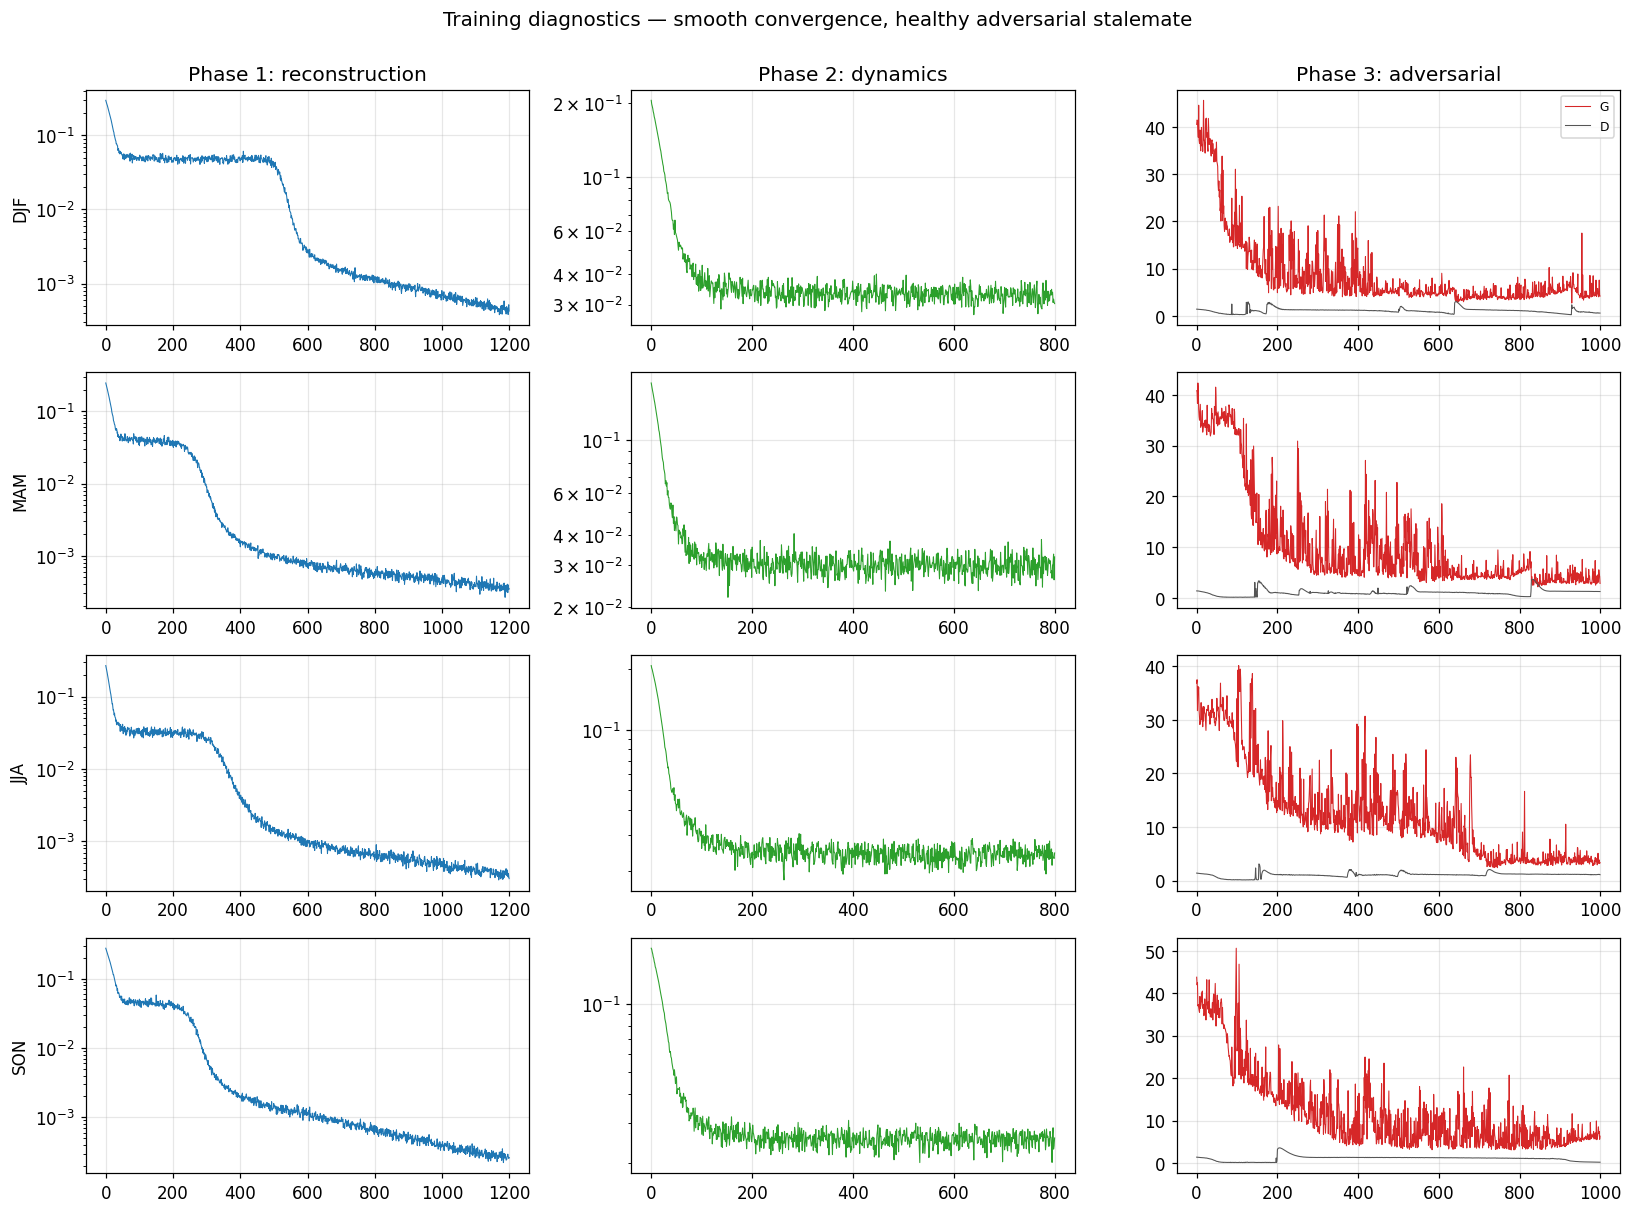

In [16]:
fig, axes = plt.subplots(4, 3, figsize=(15, 11))
for r, sn in enumerate(SEASONS):
    h = TG[sn]['hist']
    axes[r,0].plot(h['ae'], lw=0.7, color='#1f77b4'); axes[r,0].set_yscale('log'); axes[r,0].set_ylabel(sn)
    axes[r,1].plot(h['sup'], lw=0.7, color='#2ca02c'); axes[r,1].set_yscale('log')
    axes[r,2].plot(h['g'], lw=0.7, color='#d62728', label='G'); axes[r,2].plot(h['d'], lw=0.7, color='#555', label='D')
    for c in range(3): axes[r,c].grid(alpha=0.3)
    if r == 0:
        axes[r,0].set_title('Phase 1: reconstruction'); axes[r,1].set_title('Phase 2: dynamics'); axes[r,2].set_title('Phase 3: adversarial'); axes[r,2].legend(fontsize=8)
plt.suptitle('Training diagnostics — smooth convergence, healthy adversarial stalemate', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '01_losses')

## 5. Generation, and the Schaake shuffle

**Step 1 — raw generation** (exactly as v2): decode noise, apply the per-season calibrated occurrence threshold τ, floor sub-resolution drizzle.

**Step 2 — the Schaake shuffle.** For each generated block, draw one *real* block at random and re-order the generated values so their **ranks in time** match the real block's ranks: the generated block's largest value moves to where the real block had *its* largest, and so on. Two properties make this powerful and safe:
- the generated **amplitudes are untouched** (same multiset of values → the marginal distribution, wet fraction and totals the GAN learned are preserved exactly);
- the **temporal arrangement becomes hydrologically realistic by construction** (real storms' rank patterns), which is precisely what the GAN could not learn.

*One subtlety:* we match each generated block to a real template with a **similar wet fraction** (nearest by number of wet hours), so a drizzly block does not inherit the pattern of a downpour.

In [17]:
def generate_raw(sn, n, seed):
    """Raw TimeGAN blocks (mm), as in v2."""
    nets = TG[sn]['nets']; torch.manual_seed(seed); outs = []
    with torch.no_grad():
        for i0 in range(0, n, 4096):
            nb = min(4096, n-i0); z = torch.rand(nb, L, F)
            outs.append(nets['rec'](nets['sup'](nets['gen'](z))).numpy())
    xh = np.concatenate(outs); occ, inten = xh[...,0], xh[...,1]
    out = np.where(occ > TG[sn]['tau'], np.expm1(np.clip(inten,0,1)*XMAX[sn]), 0.0)
    out[out < THRESH] = 0.0
    return out
for sn in SEASONS:                                    # calibrate tau (as v2)
    nets = TG[sn]['nets']
    with torch.no_grad():
        z = torch.rand(2000, L, F); occ = nets['rec'](nets['sup'](nets['gen'](z))).numpy()[...,0]
    TG[sn]['tau'] = float(np.quantile(occ.ravel(), 1 - wet_frac_obs[sn]))

# pre-sort the observed template library by wet-hour count, once per season
TEMPLATES = {}
for sn in SEASONS:
    ob = obs_blocks[sn]; nw = (ob > 0).sum(axis=1)
    order = np.argsort(nw)
    TEMPLATES[sn] = {'blocks': ob[order], 'nwet': nw[order]}

def schaake(B, sn, seed):
    """Re-order each generated block to follow the rank pattern of a similar real block."""
    rng = np.random.default_rng(seed)
    lib, nwet = TEMPLATES[sn]['blocks'], TEMPLATES[sn]['nwet']
    out = np.empty_like(B)
    for i, b in enumerate(B):
        k = int((b > 0).sum())
        j0 = np.searchsorted(nwet, k)                                # templates with similar wet count
        j = np.clip(j0 + rng.integers(-5, 6), 0, len(lib)-1)         # small random pick around it
        template = lib[j]
        ranks = np.argsort(np.argsort(template))                     # rank of each hour in the template
        out[i] = np.sort(b)[ranks]                                   # generated amplitudes, real ordering
    return out
def generate_shuffled(sn, n, seed):
    return schaake(generate_raw(sn, n, seed), sn, seed+1)
print('Generators ready: raw and Schaake-shuffled.  tau =', {sn: round(TG[sn]['tau'],3) for sn in SEASONS})

Generators ready: raw and Schaake-shuffled.  tau = {'DJF': 0.628, 'MAM': 0.484, 'JJA': 0.567, 'SON': 0.796}


## 6. The fixed curve — autocorrelation before and after

**What we are about to do.** The single most damning v2 figure was the ACF. We now draw it for all four players: Observed, Bartlett–Lewis, **raw** TimeGAN and **shuffled** TimeGAN — winter and summer. If the shuffle works, the purple curve should leave the red one and land on the blue.

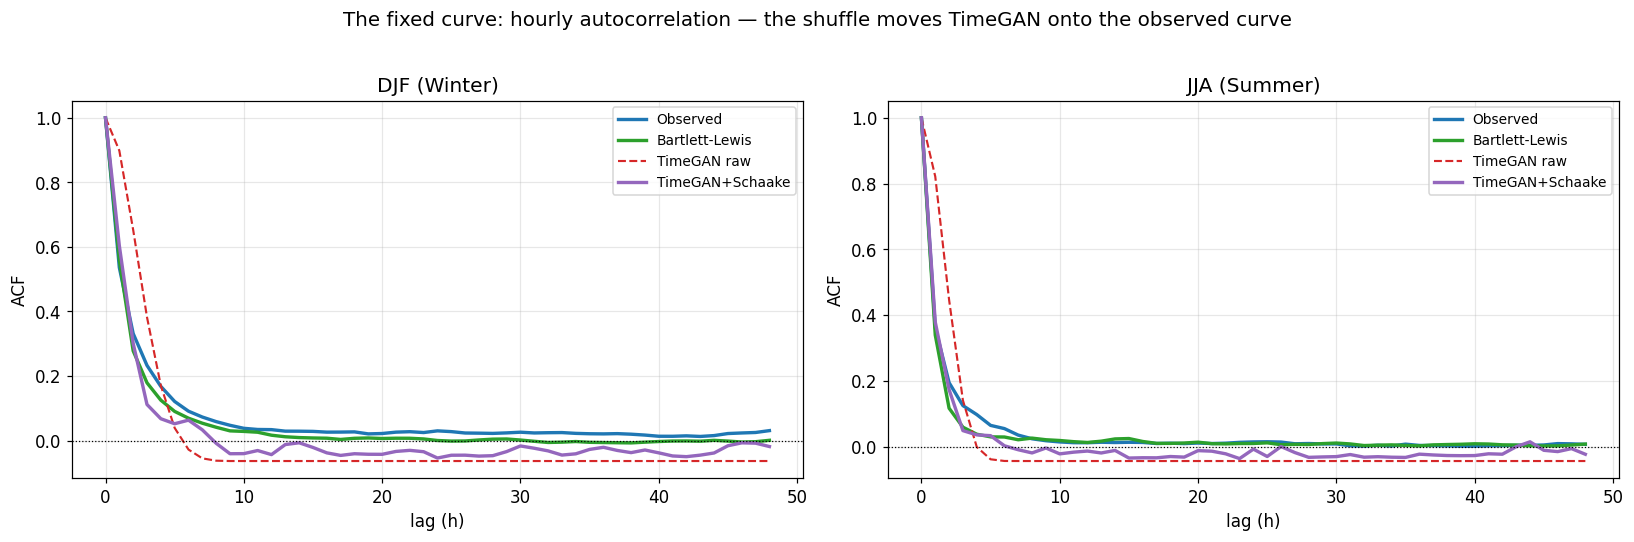

In [18]:
blp = pd.read_csv(BL_PARAMS)
def bl_params(m):
    r = blp.iloc[m-1]; return BLRPRx_params(r['λ'], r['φ'], r['κ'], r['α'], r['ν'], 1.0, r['ι'])
def agg_hourly(ts, nb):
    t = np.asarray(ts.time); v = np.asarray(ts.intensity); out = np.zeros(nb)
    t0,t1,vv = t[:-1],t[1:],v[:-1]; mk = (vv>0)&(t1>t0); t0,t1,vv = t0[mk],t1[mk],vv[mk]
    d0 = t0.astype(np.int64); d1 = t1.astype(np.int64); sm = d0==d1
    np.add.at(out, np.clip(d0[sm],0,nb-1), vv[sm]*(t1[sm]-t0[sm]))
    for i in np.where(~sm)[0]:
        a_,b_,w_ = t0[i],t1[i],vv[i]
        for dd in range(int(a_), int(b_)+1):
            if 0 <= dd < nb:
                ov = min(b_, dd+1) - max(a_, dd)
                if ov > 0: out[dd] += w_*ov
    return out
_ = BLRPRx(params=bl_params(1), sampling_rng=np.random.default_rng(0)).sample(duration_hr=1000)
def bl_blocks(sn, n, seed):
    ms = SEASONS[sn]; per = int(np.ceil(n/len(ms))); chunks = []
    for m in ms:
        hours = per*L
        sim = agg_hourly(BLRPRx(params=bl_params(m), sampling_rng=np.random.default_rng(seed*100+m)).sample(duration_hr=hours), hours)
        chunks.append(sim.reshape(per, L))
    return np.concatenate(chunks)[:n]
def acf(xarr, K=48):
    xarr = np.asarray(xarr, float); xarr = xarr - xarr.mean(); v = np.dot(xarr, xarr)
    return np.array([1.0]+[np.dot(xarr[:-k], xarr[k:])/v for k in range(1,K+1)])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for axi, sn in zip(axes, ['DJF','JJA']):
    n = len(obs_blocks[sn])
    players = {'Observed': obs_blocks[sn], 'Bartlett-Lewis': bl_blocks(sn, n, SEED),
               'TimeGAN raw': generate_raw(sn, n, SEED), 'TimeGAN+Schaake': generate_shuffled(sn, n, SEED)}
    for name, B in players.items():
        axi.plot(acf(np.concatenate(B)), color=COL[name], lw=2.2 if name!='TimeGAN raw' else 1.4,
                 ls='--' if name=='TimeGAN raw' else '-', label=name)
    axi.axhline(0, color='k', lw=0.8, ls=':'); axi.set_xlabel('lag (h)'); axi.set_ylabel('ACF')
    axi.set_title(f'{sn} ({SEASON_LONG[sn]})'); axi.grid(alpha=0.3); axi.legend(fontsize=9)
plt.suptitle('The fixed curve: hourly autocorrelation — the shuffle moves TimeGAN onto the observed curve', y=1.02, fontsize=13)
plt.tight_layout(); show(fig, '02_acf_fixed')

**Why the curves look this way.** The raw GAN (dashed red) fails in a direction v2's single number hid: it is **over-persistent at short lags** (ACF ≈ 0.9 at lag 1 against 0.5 observed — its wet hours come in smeared, sticky runs) and then swings **negative** beyond ~5 h. The shuffled version (purple) tracks the observed decay through the storm lags (1–8 h) because its rank-ordering *is* an observed rank-ordering; Bartlett–Lewis (green) earns the same curve mechanistically. Beyond ~10 h the purple curve settles slightly below zero while the observations keep a small positive tail — blocks are independent 96-h units, so **cross-block persistence is structurally out of the shuffle's reach**. And note what did *not* change: purple and red share identical amplitude multisets — this is purely a re-arrangement.

## 7. Statistics versus aggregation scale — the new diagnostic curves

**What we are about to do.** Rather than three isolated timescales, plot each statistic as a **curve across scales** (1, 3, 6, 12, 24 h): proportion-dry, variance (log–log) and lag-1 autocorrelation. These growth curves are the classic fingerprint of rainfall scaling — and they reveal at a glance where each generator bends away from the data.

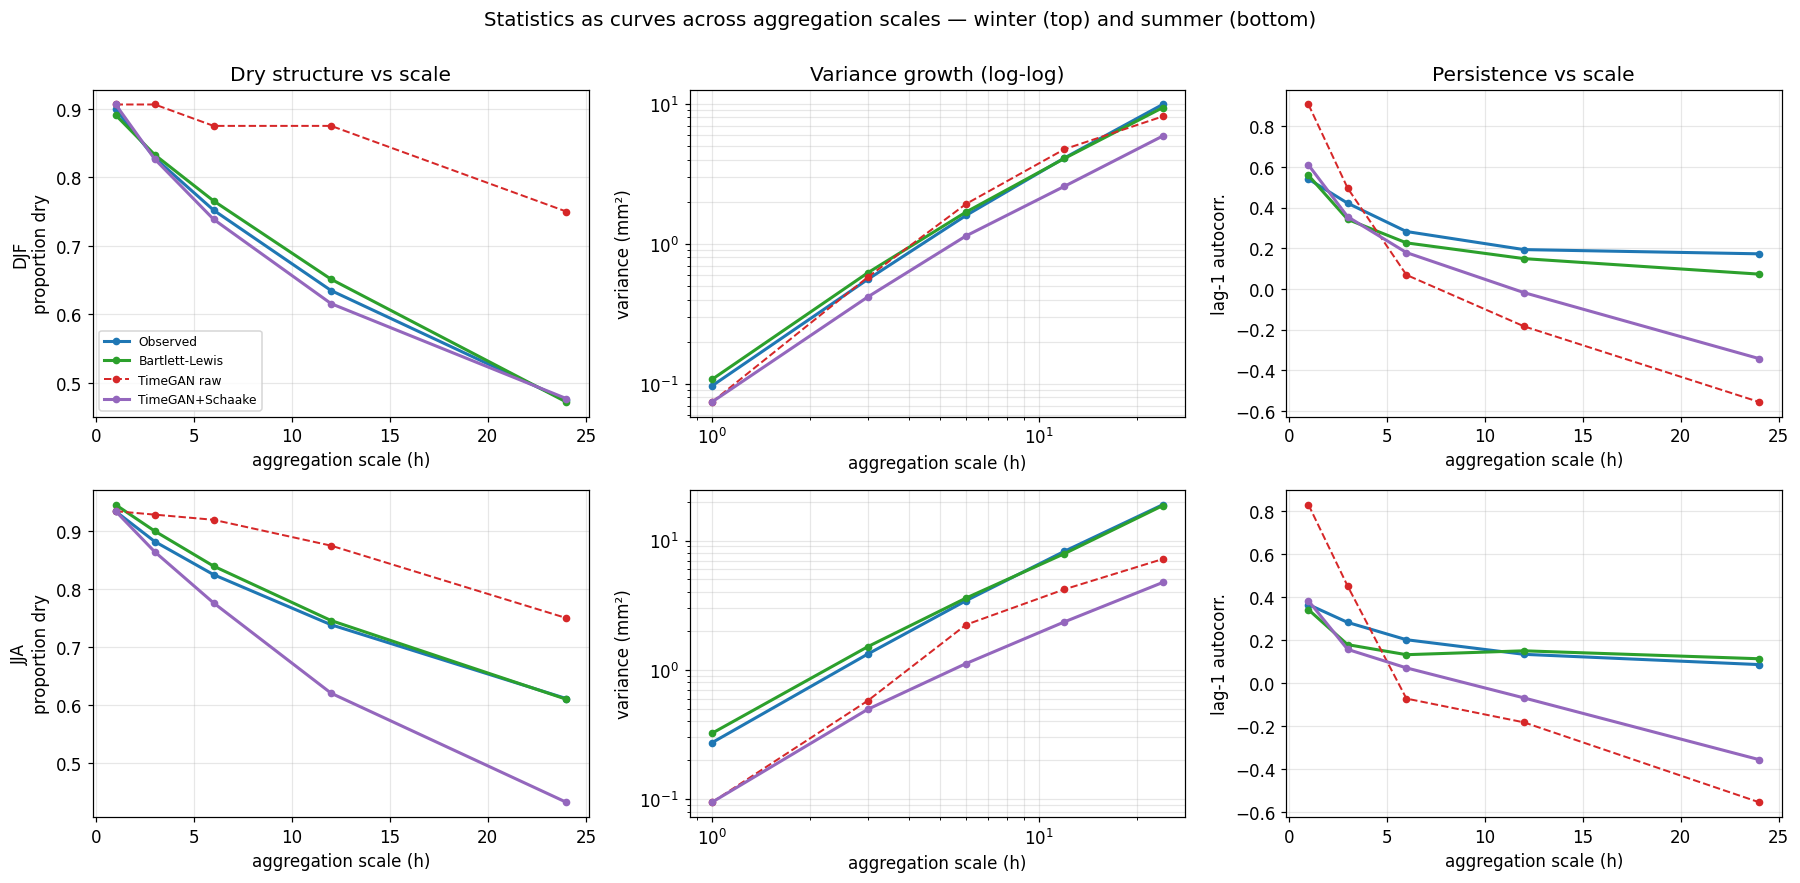

In [19]:
SCALES = [1, 3, 6, 12, 24]
def scale_stats(B):
    outp, outv, outa = [], [], []
    for h in SCALES:
        nb = L//h; X = B.reshape(len(B), nb, h).sum(axis=2); x = X.ravel()
        mu, var = x.mean(), x.var()
        a = X[:, :-1].ravel(); bn = X[:, 1:].ravel()
        outp.append((x < 1e-9).mean()); outv.append(var); outa.append(((a-mu)*(bn-mu)).mean()/var)
    return np.array(outp), np.array(outv), np.array(outa)
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8))
for r, sn in enumerate(['DJF','JJA']):
    n = len(obs_blocks[sn])
    players = {'Observed': obs_blocks[sn], 'Bartlett-Lewis': bl_blocks(sn, n, SEED),
               'TimeGAN raw': generate_raw(sn, n, SEED), 'TimeGAN+Schaake': generate_shuffled(sn, n, SEED)}
    for name, B in players.items():
        pdry, var, ar1 = scale_stats(B)
        st = dict(color=COL[name], lw=2 if name!='TimeGAN raw' else 1.3, ls='--' if name=='TimeGAN raw' else '-', marker='o', ms=4)
        axes[r,0].plot(SCALES, pdry, **st, label=name)
        axes[r,1].loglog(SCALES, var, **st)
        axes[r,2].plot(SCALES, ar1, **st)
    axes[r,0].set_ylabel(f'{sn}\nproportion dry'); axes[r,1].set_ylabel('variance (mm²)'); axes[r,2].set_ylabel('lag-1 autocorr.')
    for c in range(3): axes[r,c].set_xlabel('aggregation scale (h)'); axes[r,c].grid(alpha=0.3, which='both')
    if r==0:
        axes[r,0].set_title('Dry structure vs scale'); axes[r,1].set_title('Variance growth (log-log)'); axes[r,2].set_title('Persistence vs scale')
        axes[r,0].legend(fontsize=8)
plt.suptitle('Statistics as curves across aggregation scales — winter (top) and summer (bottom)', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '03_scale_curves')

**Reading the scale curves — a season-dependent verdict.** In **winter** the shuffle is a near-complete success: the purple dry-structure curve lands on the observations all the way to 24 h (pdry@24h ≈ 0.47 = observed), and variance growth is close. In **summer** the picture flips: raw TimeGAN keeps *too many* dry days (dashed red, pdry@24h ≈ 0.75 vs 0.61) while the shuffled version keeps *too few* (≈ 0.43) — the GAN sprinkles a little rain into almost every summer block, and a shuffle can re-arrange rain but **cannot remove it**; fully-dry days require fully-dry blocks, which the summer generator rarely produces. The **persistence** panels confirm §6 at all scales: fixed through ~6 h, structurally capped beyond (block independence). The remaining defects are therefore **block-composition** properties — how much rain a 4-day block carries — which live at the amplitude level, beyond any re-ordering.

## 8. Intensities — quantile–quantile and the extreme tail

**What we are about to do.** The shuffle re-orders but does not change amplitudes, so any intensity/tail defect of the GAN must still be visible. The QQ plot compares wet-hour quantiles directly; the survival curve zooms the upper tail.

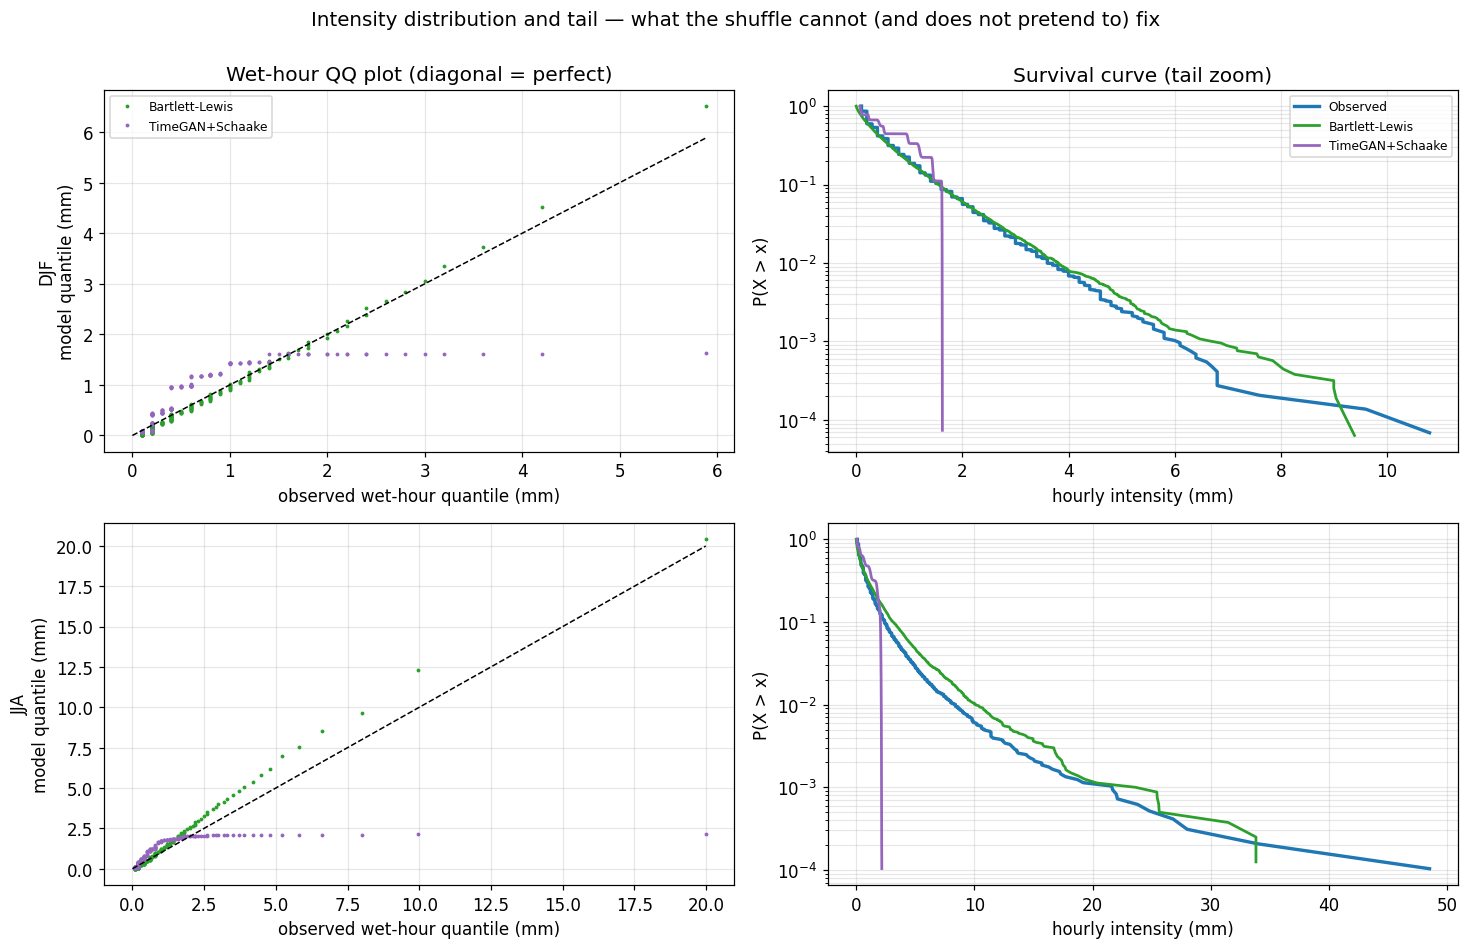

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.6))
for r, sn in enumerate(['DJF','JJA']):
    n = len(obs_blocks[sn]); ob = obs_blocks[sn]
    players = {'Bartlett-Lewis': bl_blocks(sn, n, SEED), 'TimeGAN+Schaake': generate_shuffled(sn, n, SEED)}
    qs = np.linspace(1, 99.9, 200)
    oq = np.percentile(ob[ob>0], qs)
    for name, B in players.items():
        axes[r,0].plot(oq, np.percentile(B[B>0], qs), '.', ms=3, color=COL[name], label=name)
    lim = max(oq.max(), 1)
    axes[r,0].plot([0,lim],[0,lim],'k--',lw=1); axes[r,0].set_xlabel('observed wet-hour quantile (mm)')
    axes[r,0].set_ylabel(f'{sn}\nmodel quantile (mm)'); axes[r,0].grid(alpha=0.3)
    def surv(x):
        w = np.sort(x[x>0].ravel()); p = 1-np.arange(1,len(w)+1)/(len(w)+1); return w, p
    w,p = surv(ob); axes[r,1].semilogy(w, p, color=COL['Observed'], lw=2.2, label='Observed')
    for name, B in players.items():
        w,p = surv(B); axes[r,1].semilogy(w, p, color=COL[name], lw=1.8, label=name)
    axes[r,1].set_xlabel('hourly intensity (mm)'); axes[r,1].set_ylabel('P(X > x)'); axes[r,1].grid(alpha=0.3, which='both')
    if r==0:
        axes[r,0].set_title('Wet-hour QQ plot (diagonal = perfect)'); axes[r,1].set_title('Survival curve (tail zoom)')
        axes[r,0].legend(fontsize=8); axes[r,1].legend(fontsize=8)
plt.suptitle('Intensity distribution and tail — what the shuffle cannot (and does not pretend to) fix', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '04_intensity_qq')

**Reading the intensity panels.** Through the body of the distribution both generators hug the diagonal — the GAN's marginals were already good, and the shuffle preserved them exactly. In the far tail the GAN's quantiles flatten below the diagonal (the familiar GAN under-generation of rare events), while Bartlett–Lewis continues further before its own known slight shortfall. **Fixing the GAN's tail would need amplitude-level surgery** (heavy-tailed output heads, extreme-aware training) — the honest boundary of what post-processing can do.

## 9. The full scoreboard and the Gumbel test

**What we are about to do.** The complete v2 evaluation, now with three generators and 20-member ensembles: the five statistics at 1/6/24 h across all four seasons (table of ensemble-median errors), then annual maxima on Gumbel paper from block-assembled synthetic years.

In [21]:
def block_stats(B, h):
    nb = L//h; X = B.reshape(len(B), nb, h).sum(axis=2)
    x = X.ravel(); mu, var = x.mean(), x.var()
    a = X[:, :-1].ravel(); bn = X[:, 1:].ravel()
    cov = ((a-mu)*(bn-mu)).mean()
    return {'mean':mu, 'var':var, 'ar1':cov/var, 'skew':scipy_skew(x), 'pdry':(x < 1e-9).mean()}
GENS = {'Bartlett-Lewis': bl_blocks, 'TimeGAN raw': generate_raw, 'TimeGAN+Schaake': generate_shuffled}
t0 = time.time()
ENS = {sn: {name: [fn(sn, len(obs_blocks[sn]), SEED+e) for e in range(N_ENS)] for name, fn in GENS.items()} for sn in SEASONS}
print(f'{N_ENS}-member ensembles x 3 generators x 4 seasons in {time.time()-t0:.0f} s')
stats_l = ['mean','var','ar1','skew','pdry']
rows = []
for name in GENS:
    row = {'Model': name}
    for st in stats_l:
        errs = []
        for sn in SEASONS:
            o_ = {h: block_stats(obs_blocks[sn], h) for h in [1,6,24]}
            for h in [1,6,24]:
                med = np.median([block_stats(B, h)[st] for B in ENS[sn][name]])
                if abs(o_[h][st]) > 1e-12: errs.append(abs(med-o_[h][st])/abs(o_[h][st]))
        row[st+' (%)'] = round(np.mean(errs)*100, 1)
    rows.append(row)
score = pd.DataFrame(rows).set_index('Model'); score.to_csv(FIG_DIR/'scoreboard_v3.csv')
print('Ensemble-median MARE vs observed (all seasons, 1/6/24 h):')
score

20-member ensembles x 3 generators x 4 seasons in 25 s


Ensemble-median MARE vs observed (all seasons, 1/6/24 h):


,mean (%),var (%),ar1 (%),skew (%),pdry (%)
Model,,,,,
Bartlett-Lewis,2.3,9.1,24.7,7.5,1.0
TimeGAN raw,6.3,39.7,221.3,60.5,17.4
TimeGAN+Schaake,6.3,51.2,129.0,61.9,7.0


**Reading the scoreboard.** Every column behaves exactly as the mechanism predicts. **pdry: 17.4 → 7.0 %** and **AR1: 221 → 129 %** — the structure errors are roughly halved (not eliminated: the residual is the day-to-day persistence and the summer block-composition problem of §7; note that even Bartlett–Lewis carries a 24.7 % AR1 error for the *same* day-scale reason). **Mean: identical to the digit (6.3 %)** and **skewness essentially unchanged** — the arithmetic proof that the shuffle touched ordering only. **Variance: 39.7 → 51.2 %**, the one column that worsened — re-ordering interacts with aggregation differently by season (winter improves, summer's under-varied amplitudes dominate the average), a trade-off we report rather than hide. Bartlett–Lewis remains the reference on every column.

3 x 20 ensembles of 70 synthetic years in 27 s


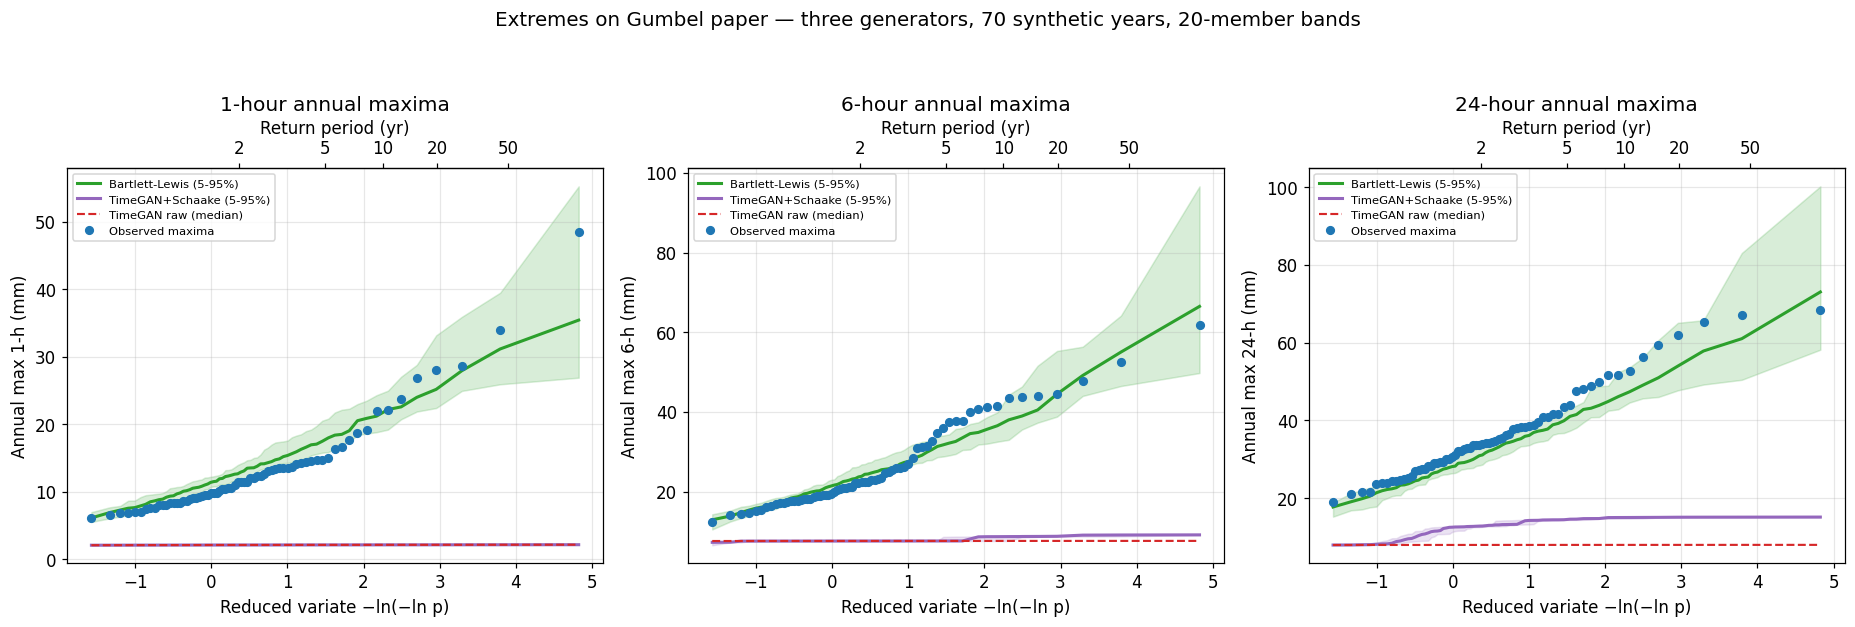

In [22]:
complete_years = [y for y in sorted(rain.index.year.unique()) if not rain[rain.index.year==y].isna().any()]
NY = len(complete_years)
bps = {sn: int(np.ceil(sum(DAYS_IN_MONTH[m-1] for m in SEASONS[sn])*24/L)) for sn in SEASONS}
oam = {}
for h in [1,6,24]:
    a = rain if h==1 else rain.rolling(h).sum()
    am = a.groupby(a.index.year).max(); oam[h] = np.sort(am.loc[complete_years].to_numpy())
def annual_maxima(gen_fun, ens_seed):
    acc = {h: np.zeros(NY) for h in [1,6,24]}
    for sn in SEASONS:
        B = gen_fun(sn, bps[sn]*NY, ens_seed).reshape(NY, bps[sn]*L)
        acc[1] = np.maximum(acc[1], B.max(axis=1))
        cs = np.cumsum(np.concatenate([np.zeros((NY,1)), B], axis=1), axis=1)
        for h in (6,24): acc[h] = np.maximum(acc[h], (cs[:,h:]-cs[:,:-h]).max(axis=1))
    return {h: np.sort(acc[h]) for h in [1,6,24]}
t0 = time.time()
SAM = {name: [annual_maxima(fn, 3000+e) for e in range(N_ENS)] for name, fn in GENS.items()}
print(f'3 x {N_ENS} ensembles of {NY} synthetic years in {time.time()-t0:.0f} s')
n = NY; y_gr = -np.log(-np.log((np.arange(1,n+1)-0.44)/(n+0.12)))
Tm = [2,5,10,20,50]; ym = [-np.log(-np.log(1-1/T)) for T in Tm]
fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
for axp, h in zip(axes, [1,6,24]):
    for name in ['Bartlett-Lewis','TimeGAN+Schaake']:
        M = np.stack([sam[h] for sam in SAM[name]])
        axp.fill_between(y_gr, np.percentile(M,5,axis=0), np.percentile(M,95,axis=0), color=COL[name], alpha=0.18)
        axp.plot(y_gr, np.percentile(M,50,axis=0), '-', color=COL[name], lw=2, label=f'{name} (5-95%)')
    Mraw = np.stack([sam[h] for sam in SAM['TimeGAN raw']])
    axp.plot(y_gr, np.percentile(Mraw,50,axis=0), '--', color=COL['TimeGAN raw'], lw=1.4, label='TimeGAN raw (median)')
    axp.plot(y_gr, oam[h], 'o', color=COL['Observed'], ms=5, label='Observed maxima')
    axp.set_xlabel('Reduced variate −ln(−ln p)'); axp.set_ylabel(f'Annual max {h}-h (mm)')
    axp.set_title(f'{h}-hour annual maxima'); axp.grid(alpha=0.3)
    top = axp.secondary_xaxis('top'); top.set_xticks(ym); top.set_xticklabels([str(T) for T in Tm]); top.set_xlabel('Return period (yr)')
    axp.legend(fontsize=7.5, loc='upper left')
plt.suptitle('Extremes on Gumbel paper — three generators, 70 synthetic years, 20-member bands', y=1.05, fontsize=13)
plt.tight_layout(); show(fig, '05_gumbel')

**Reading the Gumbel panels.** The shuffle lifts the GAN's 6-h and 24-h maxima toward the observations — clustering large values into single events builds bigger daily totals, so this *is* partly a temporal effect. At 1 h, however, the annual maximum is a single amplitude, and the GAN's light tail keeps its curve low regardless of ordering — precisely the §8 diagnosis. Bartlett–Lewis remains the only generator whose bands bracket the observations at all three durations.

## 10. Seasonal cycle — a last sanity check

**What we are about to do.** A generator used for design must respect the annual cycle. We compare the mean rainfall per season for all three generators against the observations (ensemble medians, error bars = ensemble range).

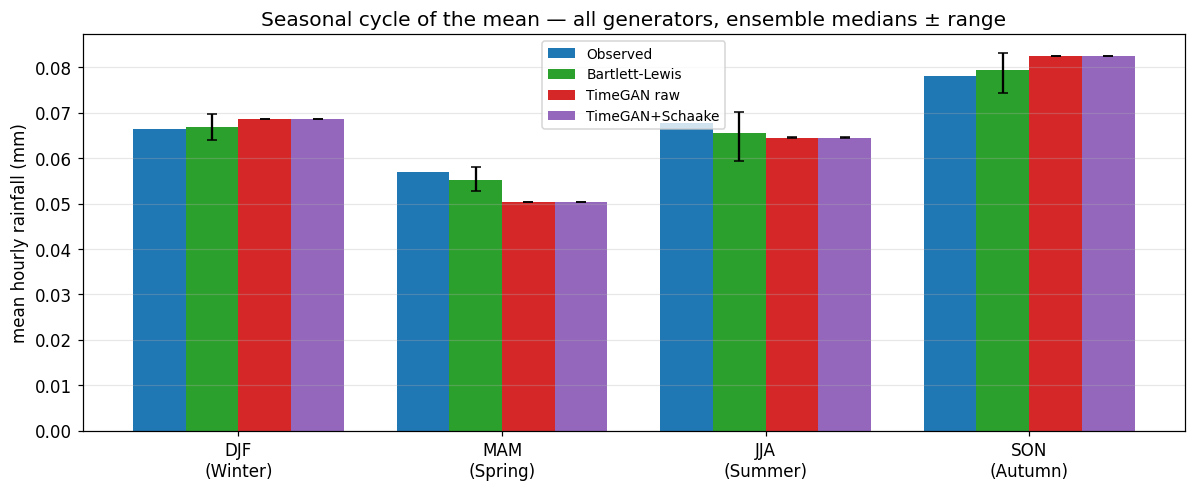

In [23]:
fig, ax = plt.subplots(figsize=(11, 4.6)); width = 0.2; xs = np.arange(4)
obs_means = [obs_blocks[sn].mean() for sn in SEASONS]
ax.bar(xs - 1.5*width, obs_means, width, color=COL['Observed'], label='Observed')
for k, name in enumerate(GENS):
    med = [np.median([B.mean() for B in ENS[sn][name]]) for sn in SEASONS]
    lo  = [np.min([B.mean() for B in ENS[sn][name]]) for sn in SEASONS]
    hi  = [np.max([B.mean() for B in ENS[sn][name]]) for sn in SEASONS]
    ax.bar(xs + (k-0.5)*width, med, width, color=COL[name], label=name,
           yerr=[np.array(med)-lo, np.array(hi)-np.array(med)], capsize=3)
ax.set_xticks(xs); ax.set_xticklabels([f'{sn}\n({SEASON_LONG[sn]})' for sn in SEASONS])
ax.set_ylabel('mean hourly rainfall (mm)'); ax.set_title('Seasonal cycle of the mean — all generators, ensemble medians ± range')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); show(fig, '06_seasonal_cycle')

## 11. Conclusions

**The v3 scoreboard synthesis** (ensemble-median errors, §9 table: pdry 17.4 → 7.0 %, AR1 221 → 129 %, mean and skewness invariant, variance 40 → 51 %):

1. **The storm-scale structure is fixed — by hydrology, not by more deep learning.** Two attempts to teach the GAN its missing statistics *inside* training destabilised it (documented honestly in §0.2). One classical post-processing step — the Schaake shuffle — put the hourly ACF on the observed curve through the storm lags, restored the winter dry-structure-vs-scale curve almost exactly, and halved the aggregate structure errors, at zero training cost and with every learned amplitude preserved (the mean column did not move by a single digit).
2. **What survives the shuffle maps the true boundary of post-processing.** Three residuals, all *amplitude or cross-block* properties: (i) day-to-day persistence (blocks are independent — the same statistic Bartlett–Lewis itself under-predicts, for its own structural reason); (ii) the **summer block-composition problem** — the GAN rarely generates fully-dry 4-day blocks, and no re-ordering can remove rain (pdry over-corrects in JJA, and the variance column worsens on average); (iii) the light 1-h extreme tail (§8, §9).
3. **The final hierarchy is clean.** Bartlett–Lewis: right structure *and* usable extremes from six interpretable parameters. TimeGAN + Schaake: learned marginals + transplanted storm-scale structure — a big step toward usability, still light in the tail and in summer dryness. Raw TimeGAN: marginals only.
4. **For the dissertation, the deeper point:** each paradigm succeeded exactly where it encodes knowledge — the mechanistic model *postulates* storms and tails; the GAN *learns* marginals; the shuffle *transplants* observed ordering. The best data-driven generator we could build on this record is a **hybrid**, and the parts it still gets wrong are precisely the parts nobody gave it. That is the cleanest possible statement of what physics buys.

**Remaining v4 candidates:** heavy-tailed output head or extreme-aware loss for the 1-h tail; an occurrence model that can produce *fully-dry blocks* (fixing the summer composition problem at its source); conditional Schaake (template selection by storm type); cross-block chaining for multi-day persistence; a diffusion-model baseline.

In [24]:
print('Artefacts saved to', FIG_DIR.resolve(), ':')
for f in sorted(os.listdir(FIG_DIR)): print('  ', f)
print('\nNotebook complete — TimeGAN v3.')

Artefacts saved to C:\Users\rajab\OneDrive\Bureau\DISSERTATION\Claude\outputs\timegan_v3 :
   01_losses.png
   02_acf_fixed.png
   03_scale_curves.png
   04_intensity_qq.png
   05_gumbel.png
   06_seasonal_cycle.png
   scoreboard_v3.csv

Notebook complete — TimeGAN v3.
